In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load data
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
frequency_table = df['Diabetes_012'].value_counts()
print("Frequency Table:")
print(frequency_table)

Frequency Table:
Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64


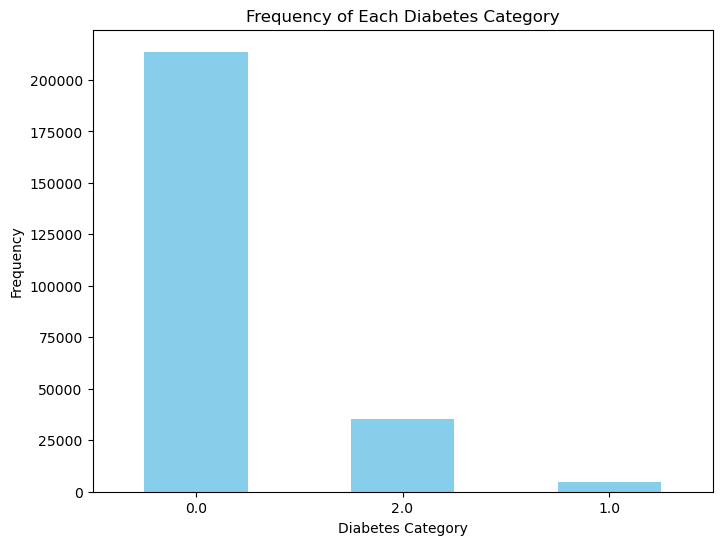

In [6]:
plt.figure(figsize=(8, 6)) 
frequency_table.plot(kind='bar', color='skyblue')

plt.title('Frequency of Each Diabetes Category')
plt.xlabel('Diabetes Category')
plt.ylabel('Frequency')
plt.xticks(rotation=0) 
plt.show()

In [10]:
# Define features
binary_cols = [
    'HighBP','HighChol','CholCheck','Smoker','Stroke',
    'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
    'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost',
    'DiffWalk','Sex'
]
ordinal_cols = ['Age','Education','Income']
continuous_cols = ['BMI']
target_cols = ['Diabetes_012']

# Convert types
df[binary_cols + ordinal_cols + target_cols] = df[binary_cols + ordinal_cols + target_cols].astype('int8')

# Cap BMI and create binary target
df['BMI'] = df['BMI'].clip(10, 80)
df['Diabetes_binary'] = (df['Diabetes_012'] > 0).astype('int8')

# Quick check
print("Shape:", df.shape)
print("Column types:\n", df.dtypes.value_counts())

# Feature summary
all_features = binary_cols + ordinal_cols + continuous_cols + ['Diabetes_012','Diabetes_binary']

def feature_summary(df, cols):
    summary = []
    for col in cols:
        dtype = df[col].dtype
        n_unique = df[col].nunique()
        missing = df[col].isna().sum()
        min_val = df[col].min() if pd.api.types.is_numeric_dtype(df[col]) else None
        max_val = df[col].max() if pd.api.types.is_numeric_dtype(df[col]) else None
        mean_val = df[col].mean() if pd.api.types.is_numeric_dtype(df[col]) else None
        summary.append({
            'Feature': col,
            'Type': str(dtype),
            'Unique / Range': f"{n_unique}" if n_unique <= 20 else f"{min_val}–{max_val}",
            'Missing': missing,
            'Mean / Typical': round(mean_val, 2) if mean_val is not None else '-'
        })
    return pd.DataFrame(summary)

feature_table = feature_summary(df, all_features)
feature_table

Shape: (253680, 23)
Column types:
 int8       19
float64     4
Name: count, dtype: int64


,Feature,Type,Unique / Range,Missing,Mean / Typical
0,HighBP,int8,2,0,0.43
1,HighChol,int8,2,0,0.42
2,CholCheck,int8,2,0,0.96
3,Smoker,int8,2,0,0.44
4,Stroke,int8,2,0,0.04
5,HeartDiseaseorAttack,int8,2,0,0.09
6,PhysActivity,int8,2,0,0.76
7,Fruits,int8,2,0,0.63
8,Veggies,int8,2,0,0.81
9,HvyAlcoholConsump,int8,2,0,0.06
